In [10]:
!pip install -q pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

In [11]:

from google.colab import drive
import pandas as pd
from pathlib import Path

# Step 1: Connect Google Drive
drive.mount('/content/drive')

# Step 2: Set project folder
project_path = Path('/content/drive/MyDrive/flywise')

# Step 3: Select dataset
dataset_path = project_path / 'flight_data_final.csv'

# Step 4: Check file exists
if not dataset_path.exists():
    raise FileNotFoundError(
        f"Dataset not found: {dataset_path}"
    )

# Step 5: Load dataset
df = pd.read_csv(dataset_path)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

# Preview first 5 rows
display(df.head())

# Display all column names
print("\nAvailable Columns:")
print(df.columns.tolist())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully!
Dataset shape: (7001619, 27)


,flight_date,reporting_airline,flight_number,origin,origin_city_name,dest,dest_city_name,crs_dep_time,dep_time,dep_delay,...,cancellation_code,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2025-01-01,AA,1,JFK,"New York, NY",LAX,"Los Angeles, CA",06:59,06:56,-3.0,...,NaN,381.0,377.0,345.0,2475.0,NaN,NaN,NaN,NaN,NaN
1,2025-01-02,AA,1,JFK,"New York, NY",LAX,"Los Angeles, CA",06:59,06:52,-7.0,...,NaN,381.0,390.0,353.0,2475.0,NaN,NaN,NaN,NaN,NaN
2,2025-01-03,AA,1,JFK,"New York, NY",LAX,"Los Angeles, CA",06:59,06:52,-7.0,...,NaN,381.0,371.0,347.0,2475.0,NaN,NaN,NaN,NaN,NaN
3,2025-01-04,AA,1,JFK,"New York, NY",LAX,"Los Angeles, CA",07:00,06:53,-7.0,...,NaN,386.0,383.0,349.0,2475.0,NaN,NaN,NaN,NaN,NaN
4,2025-01-05,AA,1,JFK,"New York, NY",LAX,"Los Angeles, CA",06:59,06:55,-4.0,...,NaN,381.0,378.0,347.0,2475.0,NaN,NaN,NaN,NaN,NaN



Available Columns:
['flight_date', 'reporting_airline', 'flight_number', 'origin', 'origin_city_name', 'dest', 'dest_city_name', 'crs_dep_time', 'dep_time', 'dep_delay', 'dep_del15', 'crs_arr_time', 'arr_time', 'arr_delay', 'arr_del15', 'cancelled', 'diverted', 'cancellation_code', 'crs_elapsed_time', 'actual_elapsed_time', 'air_time', 'distance', 'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']


In [12]:
print("Dataset Information:")
df.info()

print("\nMissing Values:")
display(df.isnull().sum().to_frame("Missing Count"))

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nSummary Statistics:")
display(df.describe(include="all").T)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7001619 entries, 0 to 7001618
Data columns (total 27 columns):
 #   Column               Dtype  
---  ------               -----  
 0   flight_date          object 
 1   reporting_airline    object 
 2   flight_number        int64  
 3   origin               object 
 4   origin_city_name     object 
 5   dest                 object 
 6   dest_city_name       object 
 7   crs_dep_time         object 
 8   dep_time             object 
 9   dep_delay            float64
 10  dep_del15            float64
 11  crs_arr_time         object 
 12  arr_time             object 
 13  arr_delay            float64
 14  arr_del15            float64
 15  cancelled            int64  
 16  diverted             int64  
 17  cancellation_code    object 
 18  crs_elapsed_time     float64
 19  actual_elapsed_time  float64
 20  air_time             float64
 21  distance             float64
 22  carrier_delay        float64
 23  weather_del

,Missing Count
flight_date,0
reporting_airline,0
flight_number,0
origin,0
origin_city_name,0
dest,0
dest_city_name,0
crs_dep_time,0
dep_time,98170
dep_delay,98591



Duplicate Rows:
0

Summary Statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
flight_date,7001619,365,2025-11-30,21576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
reporting_airline,7001619,14,WN,1391885,NaN,NaN,NaN,NaN,NaN,NaN,NaN
flight_number,7001619.0,NaN,NaN,NaN,2517.288278,1632.107165,1.0,1197.0,2270.0,3645.0,9914.0
origin,7001619,352,ORD,327028,NaN,NaN,NaN,NaN,NaN,NaN,NaN
origin_city_name,7001619,346,"Chicago, IL",401045,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dest,7001619,352,ORD,327011,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dest_city_name,7001619,346,"Chicago, IL",401029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
crs_dep_time,7001619,1359,06:00,165903,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dep_time,6903449,1440,05:55,18023,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dep_delay,6903028.0,NaN,NaN,NaN,13.556401,57.538036,-115.0,-6.0,-2.0,10.0,4352.0


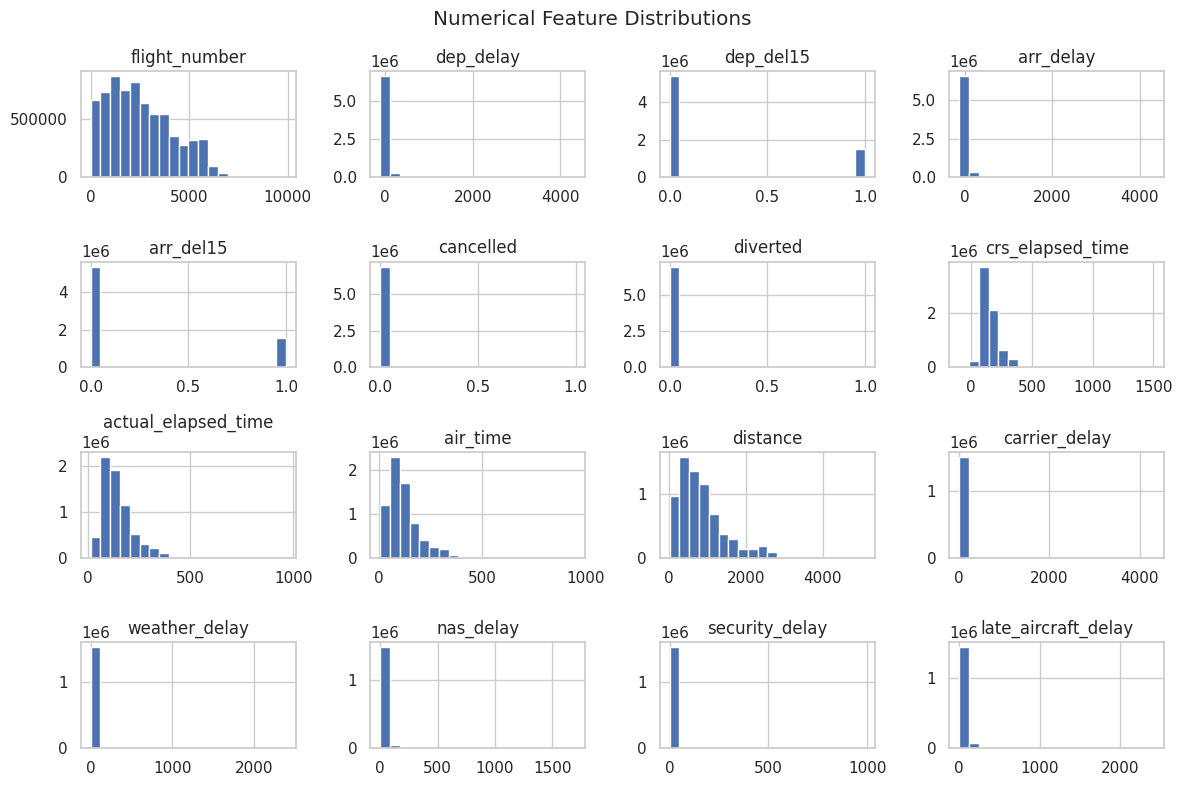

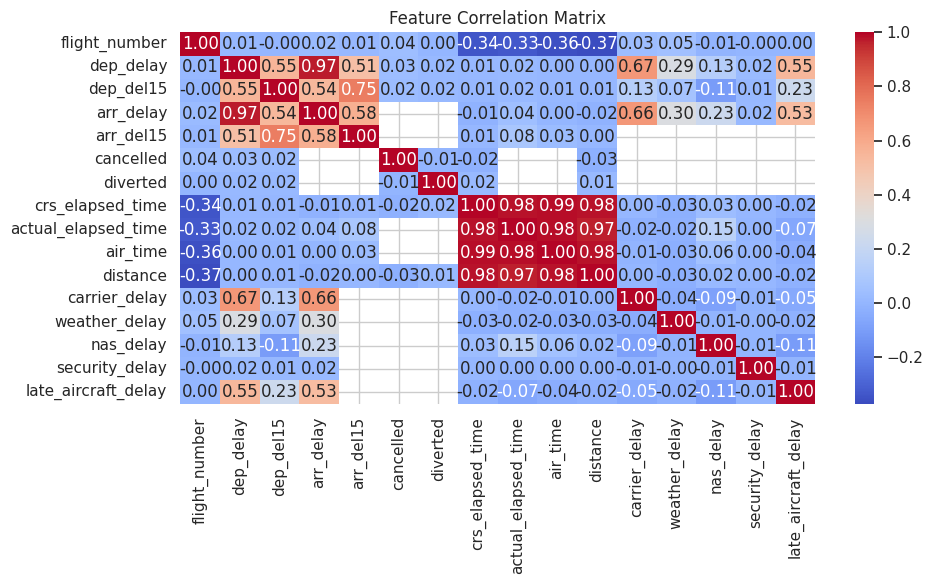

In [13]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns

if len(numeric_cols) > 0:
    df[numeric_cols].hist(
        figsize=(12, 8),
        bins=20
    )

    plt.suptitle("Numerical Feature Distributions")
    plt.tight_layout()
    plt.show()

if len(numeric_cols) >= 2:
    plt.figure(figsize=(10, 6))

    sns.heatmap(
        df[numeric_cols].corr(),
        annot=True,
        cmap="coolwarm",
        fmt=".2f"
    )

    plt.title("Feature Correlation Matrix")
    plt.tight_layout()
    plt.show()

In [14]:
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

# Export summary statistics
df.describe(include="all").T.to_csv(
    output_dir / "summary_statistics.csv"
)

# Export missing value counts
df.isnull().sum().to_csv(
    output_dir / "missing_values.csv",
    header=["Missing Count"]
)

# Export correlations
if len(numeric_cols) >= 2:
    df[numeric_cols].corr().to_csv(
        output_dir / "correlation_matrix.csv"
    )

print("Analytics results generated successfully!")

Analytics results generated successfully!


In [15]:
%%writefile requirements.txt
pandas
numpy
matplotlib
seaborn


Overwriting requirements.txt


In [16]:
%%writefile README.md
# FlyWise Analytics

## 1. Overview

This folder contains the data analytics notebook
used for exploratory analysis of the FlyWise dataset.

The analysis includes:
- Dataset inspection
- Missing value analysis
- Duplicate record checks
- Descriptive statistics
- Numerical feature distributions
- Feature correlation analysis

## 2. Folder Structure

analytics/
- analysis.ipynb
- requirements.txt
- README.md

## 3. Requirements

Python 3.10 or later is recommended.

Install the required libraries:

pip install -r requirements.txt

## 4. How to Reproduce Results

1. Open analysis.ipynb in Google Colab.
2. Run the first cell to install the dependencies.
3. Run the dataset upload cell.
4. Upload the CSV dataset used for analysis.
5. Run all remaining cells in order.
6. Review the generated tables and graphs.
7. Retrieve the exported CSV files from outputs/.

## 5. Expected Outputs

The notebook generates:
- Dataset summary statistics
- Missing value counts
- Numerical feature distributions
- Correlation matrix, where applicable

CSV results are saved in the outputs/ folder.

## 6. Notes

The notebook performs exploratory data analysis.
It does not train or evaluate the ML model.

To reproduce the same results, use the same
dataset and compatible dependency versions.

Overwriting README.md


In [17]:
from google.colab import drive
from pathlib import Path
import shutil

drive.mount("/content/drive")

# Change this to your actual project folder
project_path = Path("/content/drive/MyDrive/flywise")

analytics_path = project_path / "analytics"
analytics_path.mkdir(parents=True, exist_ok=True)

# Copy requirements and README
for filename in ["requirements.txt", "README.md"]:
    shutil.copy2(filename, analytics_path / filename)

print("Files saved to:", analytics_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files saved to: /content/drive/MyDrive/flywise/analytics
